# Building Neuro-AI Foundation Models with TorchBrain

*A minimal training setup for behavior decoding (Janelia NeuroDataReHack).*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlexandreAndr/janelia_ibl_bwm_talk/blob/main/wheel_speed_minimal_example.ipynb)

This example walks through a minimal training pipeline for **decoding behavior**
from spiking activity recorded in the **mouse brain with Neuropixels probes**,
using a single session of the IBL Brain-Wide Map. Each session records many
behavioral signals on a shared clock (wheel motion, whisker motion energy, paw
positions/speeds, and licks), any of which can be a decoding target.

<!-- TODO: check how many Neuropixels probes were inserted for this session -->

As a concrete, end-to-end example we decode **wheel speed** (a 1D continuous
signal sampled at 50 Hz). Treat it as an interactive starting point: swap in
another behavioral covariate as the target, or try the composable transforms
shown in the appendix.

The data comes from the IBL Brain-Wide Map:

[📄 Nature paper](https://www.nature.com/articles/s41586-025-09235-0){.btn .btn-outline-primary .btn-sm target="_blank"}
[🐍 ONE API](https://int-brain-lab.github.io/ONE/){.btn .btn-outline-primary .btn-sm target="_blank"}
[🧠 Interactive viz](https://viz.internationalbrainlab.org){.btn .btn-outline-primary .btn-sm target="_blank"}

It is a transparent, **self-contained** example (everything it needs lives in
this one folder) that shows how to
1. Build a custom `Dataset` on top of a `brainsets` recording (defined
   directly below, self-contained in this script).
2. Sample fixed-length trials around the decision-making task using `TrialSampler`.
3. Train one of three small decoders (a linear readout, a bidirectional GRU, or a dilated TCN).

It runs on CPU, but a GPU runtime is recommended.

## Setup

This folder is self-contained. The session is produced **by the brainset
pipeline copied alongside this script** (`ibl_brain_wide_map_2025/`), written
into the local `processed/` directory. The pipeline processes exactly the eids
listed in `ibl_brain_wide_map_2025/eval_eids.txt`, which has been trimmed to
the single session used here (the full lists are kept as `*.full.txt.bak`). To
(re)download and process it, run from this folder:

```bash
brainsets prepare ./ibl_brain_wide_map_2025 --local \
  --processed-dir ./processed --raw-dir ./raw
```

This downloads the raw IBL session via the ONE API and processes it into
`processed/ibl_brain_wide_map_2025/<recording_id>.h5` (TS1 defaults: no
QC filtering). Requires ONE API credentials; the raw download is ~5.5 GB and
the processed h5 ~1.8 GB. See this folder's `README.md` for details.

In [ ]:
# Running in Google Colab: install this notebook's pinned deps first. Colab
# starts from a blank runtime, but already has torch, scikit-learn, and
# matplotlib preinstalled, so only the packages it lacks need fetching; the
# session data itself is fetched separately from Hugging Face Hub below, so
# no repo checkout is required.
import os
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Keep this list in sync with requirements.txt.
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "torch-brain==0.2.0",
            "tqdm",
            "huggingface_hub",
        ],
        check=True,
    )

In [2]:
# This folder's own path, used to locate the local data dir regardless of cwd.
_HERE = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)

# Which eval session to decode; the h5 lands under DATA_ROOT/DATASET_DIRNAME.
DATA_ROOT = os.path.join(_HERE, "processed")
DATASET_DIRNAME = "ibl_brain_wide_map_2025"
RECORDING_ID = "0802ced5-33a3-405e-8336-b65ebc5cb07c"

In [3]:
# Fetch the pre-processed session (~1.9 GB) from the Hugging Face Hub instead of
# running the raw IBL download + brainsets pipeline (~5.5 GB raw + processing
# time). Skips the download if the file is already present locally (e.g. you
# ran `brainsets prepare` yourself). To (re)build it from scratch instead, see
# this folder's README.
_session_path = os.path.join(DATA_ROOT, DATASET_DIRNAME, f"{RECORDING_ID}.h5")
if not os.path.exists(_session_path):
    from huggingface_hub import hf_hub_download

    os.makedirs(os.path.dirname(_session_path), exist_ok=True)
    hf_hub_download(
        repo_id="AlexAndreUpenn/ibl-bwm-wheel-speed-demo",
        repo_type="dataset",
        filename=f"{RECORDING_ID}.h5",
        local_dir=os.path.join(DATA_ROOT, DATASET_DIRNAME),
    )

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor, nn
from tqdm.auto import tqdm

# Hyperparameters (feel free to play with these)
BIN_SIZE = 0.05  # seconds -> 20 spike bins over the 1.0 s context window
BATCH_SIZE = 64
EPOCHS = 100
# LR and BIN_SIZE below are the best of a grid over
# LR in {1e-4, 3e-4, 1e-3, 3e-3, 1e-2} x BIN_SIZE in {0.01, 0.02, 0.05, 0.1},
# selected by validation R² for the TCN at 200 epochs (val 0.50, test 0.30).
LR = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# The TCN's Conv1d layers see fixed input shapes, so let cuDNN autotune kernels.
torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")

## A First Look at the Data

Before building the dataset, let's see what a `brainsets` recording actually
*is*. Each session is a single, lazily-loaded object that holds every modality
on one shared time axis: the spikes of all recorded neurons, plus behavioral
covariates (wheel, whisker, paws, licks) and the trial structure.

**Materialize vs. load.** `brainsets prepare` converts the raw IBL session into
one HDF5 file on disk (~1.9 GB for this session). We never load all of that:
the `Dataset` opens the file and `data.slice(start, end)` reads back only the
short window we ask for. That is what makes training over a 65-minute session
on a laptop practical.

In [ ]:
from pathlib import Path
from typing import Literal, TypeAlias, get_args

from torch_brain.dataset import Dataset, DatasetIndex, SpikingDatasetMixin
from torch_brain.transforms import UnitFilter
from torch_brain.utils import bin_spikes

Split: TypeAlias = Literal["train", "val", "test"]


def good_units_mask(units):
    """Keep KiloSort-good, >=1 Hz units on QC-passing probes (the 'filtered' set)."""
    return (
        (np.asarray(units.label) == 1.0)
        & (np.asarray(units.firing_rate) >= 1.0)
        & (np.asarray(units.qc_neural) == b"PASS")
    )


class IBLBrainWideMap2025(SpikingDatasetMixin, Dataset):
    """
    Dataset for the IBL Brain-Wide Map (2025), for a single recording.

    Args:
        root: The root directory of the dataset.
        dirname: The name of the dataset (and the directory containing its data).
        recording_id: The recording id to load.
        split: The split of the dataset (train, val, test), or None to skip
            split-based interval filtering (e.g. when just exploring a recording).
        bin_size: The spike-binning width in seconds. Only required when the
            dataset is actually indexed (i.e. not for exploration-only use).
        filter_units: Whether to restrict to good-quality units (see
            `good_units_mask`).
    """

    # wheel speed is a 1D continuous signal, regularly sampled at BEHAVIOR_SFREQ (50 Hz).
    out_dim = 1
    spiking_dataset_mixin_uniquify_unit_ids = True
    CONTEXT_WINDOW = 1.0  # seconds
    BEHAVIOR_SFREQ = 50  # Hz

    def __init__(
        self,
        root: str,
        recording_id: str,
        dirname: str = "ibl_brain_wide_map_2025",
        split: Split | None = "train",
        bin_size: float | None = None,
        filter_units: bool = True,
    ):
        if split is not None and split not in get_args(Split):
            raise ValueError(
                f"split={split} not well defined, should be one of {get_args(Split)} or None"
            )

        # Single session used by this example (matches recording_ids.txt,
        # kept for the local/brainsets-pipeline workflow described in the
        # README).
        all_recording_ids = ["0802ced5-33a3-405e-8336-b65ebc5cb07c"]
        if recording_id not in all_recording_ids:
            raise ValueError(f"{recording_id!r} not found in recording ids")

        self.dataset_dir = Path(root) / dirname

        super().__init__(
            dataset_dir=self.dataset_dir,
            recording_ids=[recording_id],
            transform=None,
            namespace_attributes=[
                "session.id",
                "subject.id",
                "units.id",
                "probes.id",
            ],
        )

        # store some attributes that are useful later
        self.split = split
        self.recording_id = recording_id
        self.bin_size = bin_size
        self.out_sampling_rate = float(self.BEHAVIOR_SFREQ)  # 50 Hz
        # Each sample spans CONTEXT_WINDOW seconds (1.0 s).
        self.out_samples = round(self.CONTEXT_WINDOW * self.out_sampling_rate)  # 50
        self.num_bins = (
            round(self.CONTEXT_WINDOW / self.bin_size) if self.bin_size else None
        )  # 20 at 0.05 s

        # Move from the unfiltered population to the filtered (good-quality) units.
        # UnitFilter drops the spikes of non-kept units and reindexes, so downstream
        # binning just sees fewer units. num_units is the count the model will get.
        units = self.get_recording(recording_id).units
        if filter_units:
            self._unit_filter = UnitFilter(mask_fn=good_units_mask, field="spikes")
            self.num_units = int(good_units_mask(units).sum())
        else:
            self._unit_filter = None
            self.num_units = len(self.get_unit_ids())
        # Memo cache: the sampler draws the same fixed windows every epoch, and the
        # binned spikes / wheel speed for a window never change. So bin each window
        # once (epoch 1) and reuse the tensors afterwards, avoiding ~100x redundant
        # HDF5 reads + binning.
        self._cache: dict[
            tuple[str, float, float], tuple[torch.Tensor, torch.Tensor]
        ] = {}

    # Contract between Datasets and Samplers:
    # get_sampling_intervals() returns {recording_id: Interval} listing
    # the windows the sampler may draw from.
    # Sampler will emit one DatasetIndex per sample.
    def get_sampling_intervals(self, *_args, **_kwargs):
        rid = self.recording_id
        recording = self.get_recording(rid)

        # Trials aligned to the IBL decision-making task (each is a 1.0 s window).
        intervals = recording.task_aligned_intervals.domain
        # The dataset provides a causal 40/20/40 temporal train/val/test split;
        # intersect with the requested split's domain.
        intervals = intervals & getattr(recording, f"{self.split}_domain")
        # Wheel decoding is scored within the movement window of each trial.
        intervals = intervals & recording.task_aligned_intervals.movement_intervals
        # And only where the wheel signal itself is defined.
        intervals = intervals & recording.wheel._domain
        return {rid: intervals}

    # `index` is a DatasetIndex(recording_id, start, end) produced by the sampler.
    def __getitem__(self, index: DatasetIndex):
        # Return the cached tensors if we have already binned this exact window.
        key = (index.recording_id, index.start, index.end)
        if key in self._cache:
            return self._cache[key]

        # Slice the recording to this sample's time window; all modalities
        # (.spikes, .units, .wheel.speed, ...) are cropped (lazily).
        recording = self.get_recording(index.recording_id)
        data = recording.slice(index.start, index.end)

        # Keep only the good-quality units (no-op when filter_units=False).
        if self._unit_filter is not None:
            data = self._unit_filter(data)

        # All models take (num_bins, num_units) and return (out_samples, out_dim).

        # Spikes are an irregular event stream -> bin them into a regular grid.
        X = bin_spikes(data.spikes, num_units=len(data.units), bin_size=self.bin_size)
        X = torch.from_numpy(X).float()  # shape: (num_bins, num_units)

        # Wheel speed is already regularly sampled at 50 Hz. It is NOT normalized.
        Y = np.asarray(data.wheel.speed, dtype=np.float32)  # shape: (out_samples,)
        Y = torch.from_numpy(Y).unsqueeze(-1)  # shape: (out_samples, out_dim=1)

        self._cache[key] = (X, Y)
        return X, Y


# The dataset class handles file I/O; here we open the session just to explore it.
viz_ds = IBLBrainWideMap2025(root=DATA_ROOT, recording_id=RECORDING_ID, split=None)
viz_rec = viz_ds.get_recording(RECORDING_ID)
T_END = float(viz_rec.domain.end[-1])
print(f"Session length: {T_END:.0f} s ({T_END / 60:.0f} min)")
print(f"Neurons: {len(viz_rec.units.id)}  |  covariates: wheel, whisker, paws, licks")

### The full session and its causal split

The dataset splits the session **causally** in time: train is the early part,
then val, then test (a 40/20/40 temporal split). Each grey tick below is one
1.0 s window the sampler may draw a sample from.

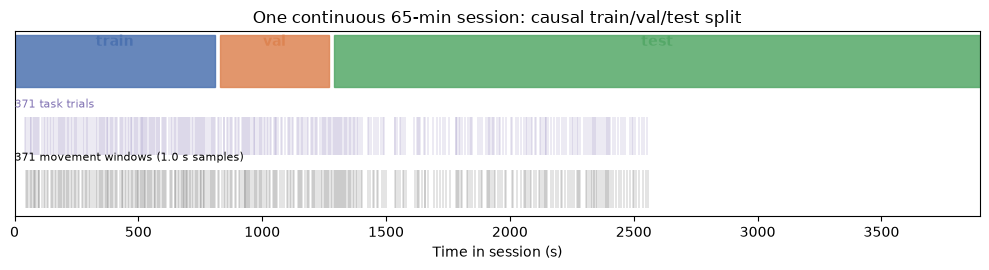

In [6]:
splits = {
    "train": (viz_rec.train_domain, "#4C72B0"),
    "val": (viz_rec.val_domain, "#DD8452"),
    "test": (viz_rec.test_domain, "#55A868"),
}
ti = viz_rec.task_aligned_intervals.domain  # 1.0 s task-aligned trial windows
mi = viz_rec.task_aligned_intervals.movement_intervals

fig, ax = plt.subplots(figsize=(10, 2.8))
for name, (dom, color) in splits.items():
    for s, e in zip(np.asarray(dom.start), np.asarray(dom.end)):
        ax.axvspan(s, e, ymin=0.70, ymax=0.98, color=color, alpha=0.85)
    mid = (float(dom.start[0]) + float(dom.end[-1])) / 2
    ax.text(mid, 1.04, name, ha="center", va="bottom", color=color, fontweight="bold")
# task-aligned trial windows: where the decision-making task actually occurs
ax.vlines(np.asarray(ti.start), 0.38, 0.62, color="#8172B3", lw=0.3, alpha=0.7)
ax.text(
    0,
    0.66,
    f"{len(ti.start)} task trials",
    ha="left",
    va="bottom",
    fontsize=8,
    color="#8172B3",
)
# movement windows: the subset used as decoding samples
ax.vlines(np.asarray(mi.start), 0.05, 0.29, color="k", lw=0.3, alpha=0.5)
ax.text(
    0,
    0.33,
    f"{len(mi.start)} movement windows (1.0 s samples)",
    ha="left",
    va="bottom",
    fontsize=8,
)
ax.set_xlim(0, T_END)
ax.set_ylim(0.0, 1.15)
ax.set_yticks([])
ax.set_xlabel("Time in session (s)")
ax.set_title(
    f"One continuous {T_END / 60:.0f}-min session: causal train/val/test split"
)
plt.tight_layout()
plt.show()

### The behavioral covariates

These are the signals available as decoding targets, shown over a 30 s window.
Movement windows are shaded green and go-cue times marked with orange dashes.
In this example we decode `wheel speed`, but the framework exposes all of them.

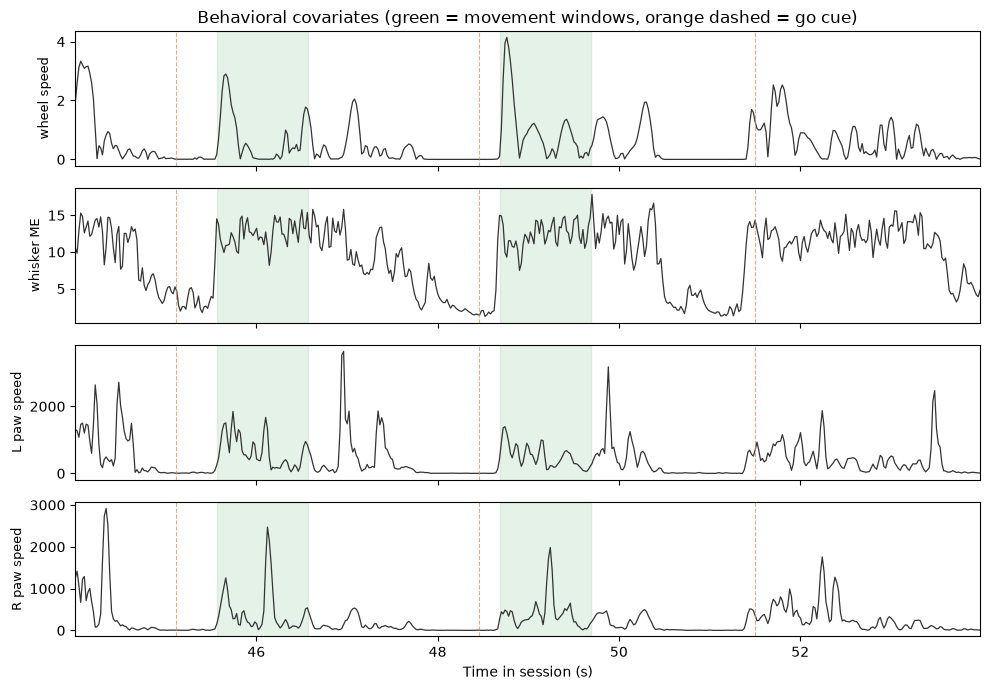

In [7]:
T0, T1 = 44.0, 54.0  # a legible 30 s window inside the training split

# Read go-cue times from a throwaway handle: accessing trials.go_cue_time on a
# recording leaves its lazy interval in a state that later breaks data.slice(),
# so we keep viz_rec clean for the materialize step below.
_go_rec = IBLBrainWideMap2025(
    root=DATA_ROOT, recording_id=RECORDING_ID, split=None
).get_recording(RECORDING_ID)
go = np.asarray(_go_rec.get_nested_attribute("trials.go_cue_time"))
go = go[(go >= T0) & (go <= T1)]
mv = [
    (s, e)
    for s, e in zip(np.asarray(mi.start), np.asarray(mi.end))
    if s >= T0 and e <= T1
]

covariates = [
    ("wheel", "speed", "wheel speed"),
    ("whisker", "motion_energy", "whisker ME"),
    ("paws", "left_paw_speed", "L paw speed"),
    ("paws", "right_paw_speed", "R paw speed"),
]
fig, axes = plt.subplots(len(covariates), 1, figsize=(10, 7), sharex=True)
for ax, (ns, attr, label) in zip(axes, covariates):
    obj = getattr(viz_rec, ns)
    ts = np.asarray(obj.timestamps)
    msk = (ts >= T0) & (ts <= T1)
    ax.plot(ts[msk], np.asarray(getattr(obj, attr))[msk], lw=0.9, color="#333333")
    for s, e in mv:
        ax.axvspan(s, e, color="#55A868", alpha=0.15)
    for g in go:
        ax.axvline(g, color="#DD8452", lw=0.8, ls="--", alpha=0.7)
    ax.set_ylabel(label, fontsize=9)
    ax.margins(x=0)
axes[0].set_title(
    "Behavioral covariates (green = movement windows, orange dashed = go cue)"
)
axes[-1].set_xlabel("Time in session (s)")
plt.tight_layout()
plt.show()

### Spikes, and how a sample is carved out

The spikes are an irregular event stream over the whole session. The sampler
picks fixed 1.0 s windows out of it (one highlighted below); everything outside
the window is simply never read.

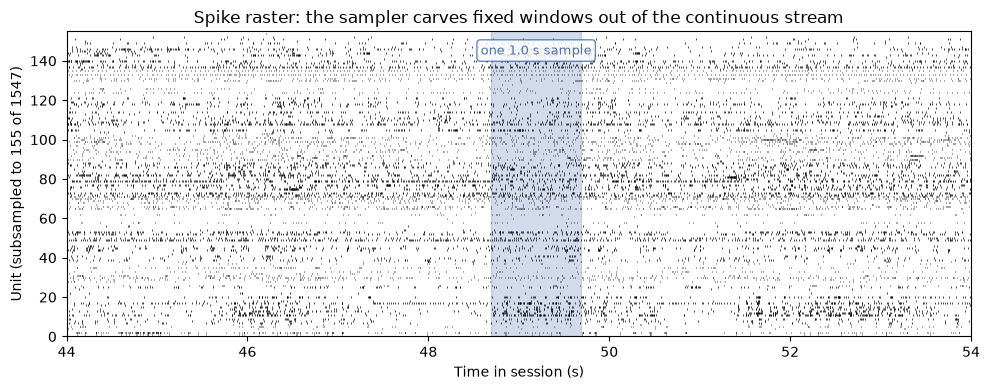

In [8]:
allt = np.asarray(viz_rec.spikes.timestamps)
allu = np.asarray(viz_rec.spikes.unit_index)
wm = (allt >= T0) & (allt <= T1)
st, ui = allt[wm], allu[wm]

# subsample ~150 units so the raster stays legible
n_units = len(viz_rec.units.id)
keep = np.arange(0, n_units, max(1, n_units // 150))
row_of = {u: i for i, u in enumerate(keep)}
m = np.isin(ui, keep)
rows = np.array([row_of[u] for u in ui[m]])

# highlight one real sampling window (task-aligned & movement & wheel-defined)
sample_iv = (
    viz_rec.task_aligned_intervals.domain
    & viz_rec.train_domain
    & viz_rec.task_aligned_intervals.movement_intervals
    & viz_rec.wheel._domain
)
in_win = [
    (s, e)
    for s, e in zip(np.asarray(sample_iv.start), np.asarray(sample_iv.end))
    if s >= T0 and e <= T1
]
hs, he = in_win[len(in_win) // 2]

fig, ax = plt.subplots(figsize=(10, 4))
spikes_by_row = [st[m][rows == r] for r in range(len(keep))]
ax.eventplot(
    spikes_by_row,
    colors="k",
    lineoffsets=list(range(len(keep))),
    linelengths=0.8,
    linewidths=0.5,
)
ax.axvspan(hs, he, color="#4C72B0", alpha=0.25)
ax.text(
    (hs + he) / 2,
    len(keep) * 0.96,
    "one 1.0 s sample",
    color="#4C72B0",
    fontsize=9,
    ha="center",
    va="top",
    bbox=dict(boxstyle="round", fc="white", ec="#4C72B0", alpha=0.85),
)
ax.set_xlim(T0, T1)
ax.set_ylim(0, len(keep))
ax.set_xlabel("Time in session (s)")
ax.set_ylabel(f"Unit (subsampled to {len(keep)} of {n_units})")
ax.set_title(
    "Spike raster: the sampler carves fixed windows out of the continuous stream"
)
plt.tight_layout()
plt.show()

### The materialized sample

Finally, `data.slice(start, end)` returns exactly that window, and binning the
spikes turns it into the `(bins x units)` input `X`; the aligned wheel speed is
the target `Y`. This `(X, Y)` pair is precisely what the model will see.

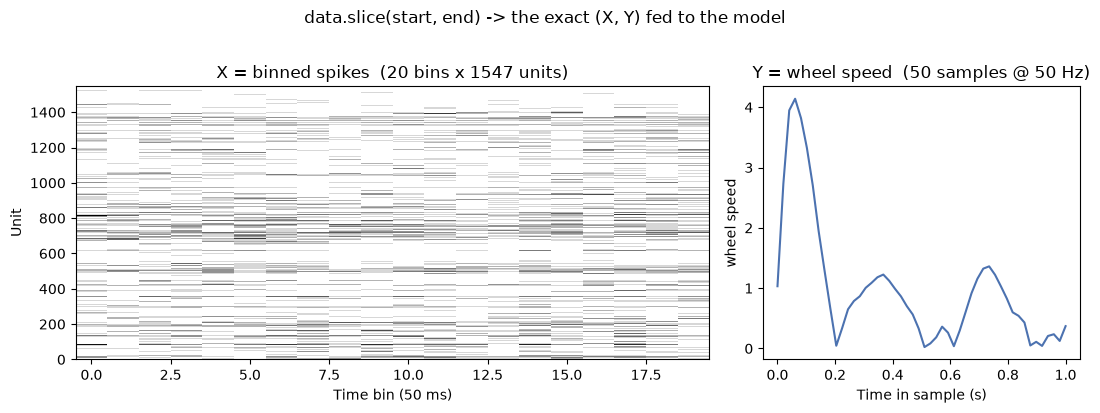

In [9]:
sample = viz_rec.slice(hs, he)
X_demo = bin_spikes(sample.spikes, num_units=len(sample.units), bin_size=BIN_SIZE)
Y_demo = np.asarray(sample.wheel.speed, dtype=np.float32)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
# log1p for contrast: per-bin counts are small, so raw values look nearly blank
axes[0].imshow(
    np.log1p(X_demo.T),
    aspect="auto",
    cmap="Greys",
    origin="lower",
    interpolation="nearest",
)
axes[0].set_title(
    f"X = binned spikes  ({X_demo.shape[0]} bins x {X_demo.shape[1]} units)"
)
axes[0].set_xlabel(f"Time bin ({BIN_SIZE * 1000:.0f} ms)")
axes[0].set_ylabel("Unit")
tt = np.linspace(0, 1.0, len(Y_demo))
axes[1].plot(tt, Y_demo, color="#4C72B0")
axes[1].set_title(f"Y = wheel speed  ({len(Y_demo)} samples @ 50 Hz)")
axes[1].set_xlabel("Time in sample (s)")
axes[1].set_ylabel("wheel speed")
fig.suptitle("data.slice(start, end) -> the exact (X, Y) fed to the model", y=1.02)
plt.tight_layout()
plt.show()

## Defining a Simple & Custom Dataset

`IBLBrainWideMap2025` (defined above) is a self-contained, `brainsets`-backed
dataset for a single recording. Two methods matter for the wheel-speed task:
- **`get_sampling_intervals`**: Decides *which* time windows count as samples.
  For wheel-speed decoding, each sample is a fixed **1.0 s** window drawn from
  the trials of the IBL decision-making task, restricted to the movement window
  and to the times where the wheel signal is defined. We use the dataset's
  built-in **causal** train/val/test split (`{split}_domain`): a temporal
  40/20/40 split, so train is early in the session and test is late.
- **`__getitem__`**: Given a time-sliced sample, turns it into model Tensors.

Note: `wheel_speed` is intentionally **not normalized** (unlike the
pixel-valued whisker/paw signals), so we use the raw signal as the target.
(If you swap in another covariate as the target, normalization may matter.)

**Unfiltered vs. filtered units.** The recording ships with *all*
recorded units (the TS1 default: no QC filtering). We move to the **filtered**
set here via a `UnitFilter` transform that keeps only good-quality units:
`label == 1.0` (KiloSort "good") AND `firing_rate >= 1 Hz` AND
`qc_neural == PASS` (probe QC). For this session that is **1547 -> 358 units**.
Fewer, higher-quality units means a much lower-dimensional input, which
directly reduces the overfitting we saw with the full population.


## Creating the Datasets, Samplers, and DataLoaders

💡 This is where we come across the main pattern for creating data pipelines with TorchBrain:
- **Dataset** tells the sampler *where sampling is allowed*,
- **Sampler** decides *what* samples to load (by emitting `DatasetIndex` objects), and
- **DataLoader** batches the samples as usual.

In [ ]:
from torch.utils.data import DataLoader  # standard PyTorch loader
from torch_brain.samplers import TrialSampler

train_ds = IBLBrainWideMap2025(
    DATA_ROOT, split="train", bin_size=BIN_SIZE, recording_id=RECORDING_ID
)
# We want to sample "one-trial-at-a-time", so we use the TrialSampler
train_sampler = TrialSampler(
    sampling_intervals=train_ds.get_sampling_intervals(),
    shuffle=True,
)
# Note the sampler is passed explicitly; it is not the default random/sequential
# sampler PyTorch picks for an indexable dataset.
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
)
print(f"Number of units: {train_ds.num_units}")
print(f"Number of training samples: {len(train_sampler)}")

# Validation Dataset, Sampler, and DataLoader
val_ds = IBLBrainWideMap2025(
    DATA_ROOT, split="val", bin_size=BIN_SIZE, recording_id=RECORDING_ID
)
val_sampler = TrialSampler(sampling_intervals=val_ds.get_sampling_intervals())
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    sampler=val_sampler,
)
print(f"Number of validation samples: {len(val_sampler)}")

# Test Dataset, Sampler, and DataLoader.
# The test split is the *late* part of the session (causal split). We touch it
# only once, for the final score after training/model selection is done.
test_ds = IBLBrainWideMap2025(
    DATA_ROOT, split="test", bin_size=BIN_SIZE, recording_id=RECORDING_ID
)
test_sampler = TrialSampler(sampling_intervals=test_ds.get_sampling_intervals())
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    sampler=test_sampler,
)
print(f"Number of test samples: {len(test_sampler)}")

print(f"Number of units:  {train_ds.num_units}")
print(f"Bins per sample:  {train_ds.num_bins}  (bin size = {BIN_SIZE}s)")
print(f"Target samples:   {train_ds.out_samples}  (at {train_ds.out_sampling_rate} Hz)")
print(
    f"Train trials:     {len(train_ds.get_sampling_intervals()[train_ds.recording_id])}"
)
print(f"Val trials:       {len(val_ds.get_sampling_intervals()[val_ds.recording_id])}")

Let's first peek at a single sample to confirm the shapes match what we expect,
and visualize the binned spikes (input) and wheel speed (target) for one trial.

First sample:
    recording_id: 0802ced5-33a3-405e-8336-b65ebc5cb07c,
    start time: 562.1847552706807,
    end time: 563.1847552706807

X shape: (20, 358)  (num_bins, num_units)
Y shape: (50, 1)  (out_samples, out_dim)


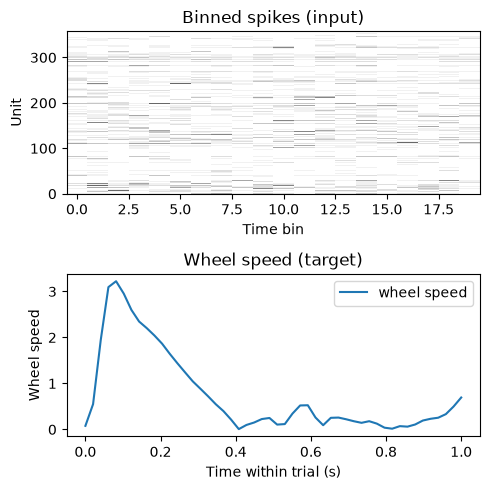

In [11]:
first_sample_index = next(iter(train_sampler))
print(
    f"First sample:\n"
    f"    recording_id: {first_sample_index.recording_id},\n"
    f"    start time: {first_sample_index.start},\n"
    f"    end time: {first_sample_index.end}\n"
)

X, Y = train_ds[first_sample_index]
print(f"X shape: {tuple(X.shape)}  (num_bins, num_units)")
print(f"Y shape: {tuple(Y.shape)}  (out_samples, out_dim)")

fig, axes = plt.subplots(2, 1, figsize=(5, 5))

axes[0].imshow(
    X.T.numpy(), aspect="auto", cmap="Greys", origin="lower", interpolation="nearest"
)
axes[0].set_title("Binned spikes (input)")
axes[0].set_xlabel("Time bin")
axes[0].set_ylabel("Unit")

t = np.linspace(0.0, train_ds.CONTEXT_WINDOW, train_ds.out_samples)
axes[1].plot(t, Y[:, 0].numpy(), label="wheel speed")
axes[1].set_title("Wheel speed (target)")
axes[1].set_xlabel("Time within trial (s)")
axes[1].set_ylabel("Wheel speed")
axes[1].legend()

plt.tight_layout()
plt.show()

## The Model

Three small decoders are defined in the cells below: Linear, GRU, and TCN.

- **Linear**: flatten + a single `nn.Linear` layer.
- **GRU**: bidirectional GRU, then a per-timestep linear readout and an
  interpolation to upsample from `num_bins` to `out_samples`.
- **TCN**: a stack of dilated 1D convolutions, followed by the same
  interpolation + readout.

All three follow the same interface. They take `(batch, num_bins, num_units)`
and return `(batch, out_samples, out_dim)`.

### Linear

In [12]:
class Linear(nn.Module):
    def __init__(self, in_units, in_bins, out_dim, out_samples, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        self.out_samples = out_samples

        input_size = in_units * in_bins
        output_size = out_dim * out_samples
        self.net = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(input_size, output_size)
        )

    def forward(self, x: Tensor) -> Tensor:
        batch_size = x.size(0)
        y = self.net(x.flatten(start_dim=1))
        y = y.view(batch_size, self.out_samples, self.out_dim)
        return y

### GRU

In [13]:
class GRU(nn.Module):
    def __init__(
        self,
        in_units,
        in_bins,
        out_dim,
        out_samples,
        hidden_dim=64,
        num_layers=2,
        bidirectional=True,
        dropout=0.2,
    ):
        super().__init__()
        self.out_dim = out_dim
        self.out_samples = out_samples

        self.gru = nn.GRU(
            input_size=in_units,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout,
        )
        self.readout = nn.Linear(
            in_features=2 * hidden_dim if bidirectional else hidden_dim,
            out_features=out_dim,
        )

    def forward(self, x: Tensor) -> Tensor:
        z, _ = self.gru(x)
        y = self.readout(z)
        y = y.permute(0, 2, 1)  # (B, T, D) ->  (B, D, T)
        y = nn.functional.interpolate(y, self.out_samples, mode="linear")
        y = y.permute(0, 2, 1)  # (B, D, T) -> (B, T, D)
        return y

### TCN

In [14]:
class TCN(nn.Module):
    def __init__(
        self,
        in_units,
        in_bins,
        out_dim,
        out_samples,
        hidden_dim=64,
        num_layers=8,
        kernel_size=3,
        dropout=0.2,
    ):
        super().__init__()
        self.out_dim = out_dim
        self.out_samples = out_samples

        layers = []
        in_channels = in_units
        for i in range(num_layers):
            dilation = 2**i
            padding = (kernel_size - 1) * dilation // 2
            layers.append(nn.Dropout(dropout))
            layers.append(
                nn.Conv1d(
                    in_channels,
                    hidden_dim,
                    kernel_size,
                    padding=padding,
                    dilation=dilation,
                )
            )
            layers.append(nn.ReLU())
            in_channels = hidden_dim
        self.net = nn.Sequential(*layers)
        self.readout = nn.Linear(hidden_dim, out_dim)

    def forward(self, x: Tensor) -> Tensor:
        z = x.permute(0, 2, 1)  # (B, T, C) -> (B, C, T)
        z = self.net(z)
        z = nn.functional.interpolate(z, self.out_samples, mode="linear")
        z = z.permute(0, 2, 1)  # (B, C, T) -> (B, T, C)
        y = self.readout(z)
        return y

### Instantiating the model

In [15]:
model = TCN(  # try: Linear, GRU, TCN
    in_units=train_ds.num_units,
    in_bins=train_ds.num_bins,
    out_dim=train_ds.out_dim,
    out_samples=train_ds.out_samples,
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {num_params:,}")
print(model)


Trainable parameters: 155,329
TCN(
  (net): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Conv1d(358, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
    (8): ReLU()
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
    (11): ReLU()
    (12): Dropout(p=0.2, inplace=False)
    (13): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
    (17): ReLU()
    (18): Dropout(p=0.2, inplace=False)
    (19): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(64,), 

## Training

A standard PyTorch loop! MSE loss against the wheel speed, AdamW optimizer,
R² score on the validation set at the end of each epoch.

In [16]:
from sklearn.metrics import r2_score

optim = torch.optim.AdamW(model.parameters(), lr=LR)

val_r2_history = []

for _epoch in (epoch_pbar := tqdm(range(EPOCHS))):
    model.train()
    for X, Y in train_loader:
        X, Y = X.to(device), Y.to(device)
        pred = model(X)
        loss = nn.functional.mse_loss(pred, Y)
        optim.zero_grad()
        loss.backward()
        optim.step()

    with torch.no_grad():
        model.eval()
        preds, targets = [], []
        for X, Y in val_loader:
            X, Y = X.to(device), Y.to(device)
            preds.append(model(X))
            targets.append(Y)
        pred = torch.cat(preds).flatten(0, 1).cpu()
        target = torch.cat(targets).flatten(0, 1).cpu()
        r2 = r2_score(target, pred)
        val_r2_history.append(r2)
        epoch_pbar.set_description(f"Val R²: {r2:.3f}")


  0%|                                                                                                                      | 0/200 [00:00<?, ?it/s]


Val R²: -0.866:   0%|                                                                                                      | 0/200 [00:00<?, ?it/s]


Val R²: -0.866:   0%|▍                                                                                             | 1/200 [00:00<02:44,  1.21it/s]


Val R²: -0.861:   0%|▍                                                                                             | 1/200 [00:01<02:44,  1.21it/s]


Val R²: -0.861:   1%|▉                                                                                             | 2/200 [00:01<01:55,  1.72it/s]

...


Val R²: 0.273:  96%|████████████████████████████████████████████████████████████████████████████████████████▊    | 191/200 [00:03<00:00, 93.14it/s]


Val R²: 0.278:  96%|████████████████████████████████████████████████████████████████████████████████████████▊    | 191/200 [00:03<00:00, 93.14it/s]


Val R²: 0.276:  96%|████████████████████████████████████████████████████████████████████████████████████████▊    | 191/200 [00:03<00:00, 93.14it/s]


Val R²: 0.275:  96%|████████████████████████████████████████████████████████████████████████████████████████▊    | 191/200 [00:03<00:00, 93.14it/s]


Val R²: 0.275: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 50.34it/s]

## Evaluation

Plot the R² curve over training and compare predicted vs. actual wheel speed
on one validation trial.

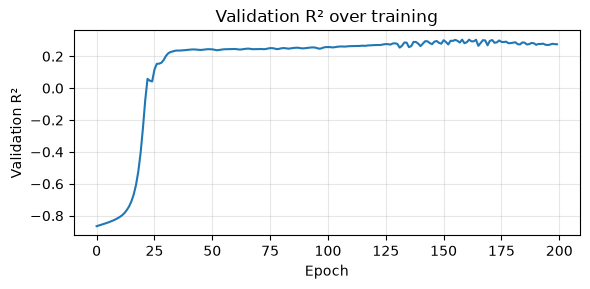

In [17]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(val_r2_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation R²")
ax.set_title("Validation R² over training")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Let's look at an example of how our model's predictions compare with the ground truth!

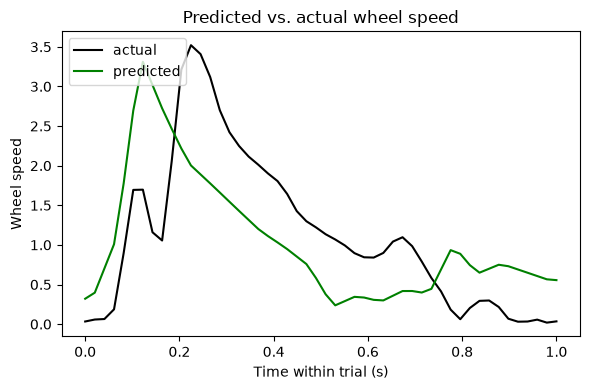

In [18]:
model.eval()
with torch.no_grad():
    X, Y = val_ds[next(iter(val_sampler))]
    pred = model(X.unsqueeze(0).to(device)).squeeze(0).cpu()

t = np.linspace(0.0, val_ds.CONTEXT_WINDOW, val_ds.out_samples)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, Y[:, 0].numpy(), label="actual", color="k")
ax.plot(t, pred[:, 0].numpy(), label="predicted", color="green")
ax.set_xlabel("Time within trial (s)")
ax.set_ylabel("Wheel speed")
ax.set_title("Predicted vs. actual wheel speed")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

## Final Test Evaluation

The **test** split is the *late* portion of the session (the causal split), held
out from training and model selection. We score it exactly **once**, here, to get
an honest estimate of decoding performance. Because the split is temporal rather
than shuffled, test R² is typically **lower** than validation R² -- that gap
reflects within-session nonstationarity, which is exactly what a causal split is
designed to expose.

In [19]:
model.eval()
with torch.no_grad():
    preds, targets = [], []
    for X, Y in test_loader:
        X, Y = X.to(device), Y.to(device)
        preds.append(model(X))
        targets.append(Y)
    test_pred = torch.cat(preds).flatten(0, 1).cpu()
    test_target = torch.cat(targets).flatten(0, 1).cpu()

test_r2 = r2_score(test_target, test_pred)
best_val_r2 = max(val_r2_history)
print(f"Best validation R²: {best_val_r2:.3f}")
print(f"Final test R²:      {test_r2:.3f}")

Best validation R²: 0.304
Final test R²:      -0.080


And the predicted vs. actual wheel speed on one held-out test trial:

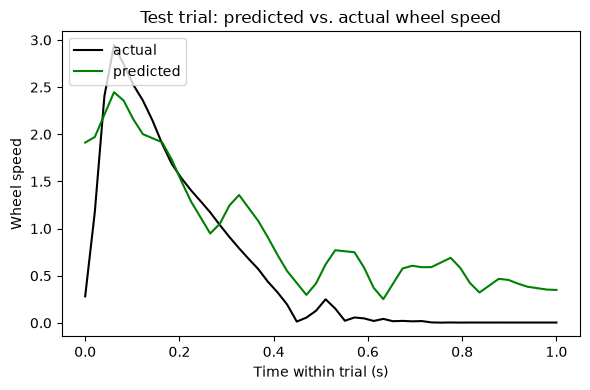

In [20]:
model.eval()
with torch.no_grad():
    X, Y = test_ds[next(iter(test_sampler))]
    pred = model(X.unsqueeze(0).to(device)).squeeze(0).cpu()

t = np.linspace(0.0, test_ds.CONTEXT_WINDOW, test_ds.out_samples)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, Y[:, 0].numpy(), label="actual", color="k")
ax.plot(t, pred[:, 0].numpy(), label="predicted", color="green")
ax.set_xlabel("Time within trial (s)")
ax.set_ylabel("Wheel speed")
ax.set_title("Test trial: predicted vs. actual wheel speed")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

---
# Appendix: Why this framework is powerful

The training pipeline above is four independent pieces: **Dataset** (*where* to
sample), **Sampler** (*which* windows), **Transform** (*how* to process), and
**DataLoader** (*how* to batch). Because they are decoupled, common neuroscience
experiments (finer binning, more context, augmentation, region ablations,
jittered sampling) are each a **one-line change that never touches the model or
the training loop**.

Every cell below is illustrative: it operates on a single demo window and does
**not** modify the tuned pipeline above.

In [21]:
from torch_brain.samplers import RandomFixedWindowSampler
from torch_brain.transforms import Compose, RandomCrop, UnitDropout

# a clean recording handle + one real sampling window to demo on
demo_ds = IBLBrainWideMap2025(root=DATA_ROOT, recording_id=RECORDING_ID, split=None)
demo_rec = demo_ds.get_recording(RECORDING_ID)
demo_iv = (
    demo_rec.task_aligned_intervals.domain
    & demo_rec.train_domain
    & demo_rec.task_aligned_intervals.movement_intervals
    & demo_rec.wheel._domain
)
DEMO_T0 = float(demo_iv.start[10])
print(f"Demo window starts at {DEMO_T0:.2f} s")

Demo window starts at 93.46 s


## 1. Lazy loading and the time gain

A `brainsets` recording is memory-mapped: `data.slice(start, end)` reads only
the bytes for the window you ask for. You open a ~2 GB session in milliseconds
and each sample touches a tiny slice of it, so you never hold the session (or
even one full modality) in RAM. That is what makes training over a 65-min
session, or scaling to many sessions, feasible at all.

The catch (see the caching in `IBLBrainWideMap2025`): lazy is cheap *per
call* but you redo it *every epoch*. So the sweet spot is **lazy + selective
materialization**: never eagerly load the whole file, but cache the handful of
windows you actually sample, once. Lazy decides what you *never* load; the cache
decides what you load *only once*.

In [22]:
import os
import time

fpath = os.path.join(DATA_ROOT, "ibl_brain_wide_map_2025", f"{RECORDING_ID}.h5")
print(f"session file on disk:       {os.path.getsize(fpath) / 1e9:5.2f} GB")

t = time.time()
_d = IBLBrainWideMap2025(root=DATA_ROOT, recording_id=RECORDING_ID, split=None)
_r = _d.get_recording(RECORDING_ID)
t_open = time.time() - t

t = time.time()
for _ in range(20):
    _s = _r.slice(DEMO_T0, DEMO_T0 + 1.0)
    _ = bin_spikes(_s.spikes, num_units=len(_s.units), bin_size=BIN_SIZE)
t_slice = (time.time() - t) / 20

t = time.time()
_allt = np.asarray(_r.spikes.timestamps)
t_all = time.time() - t

print(f"open dataset (lazy):        {t_open * 1000:5.1f} ms   (reads no signals)")
print(
    f"one 1.0 s window slice+bin: {t_slice * 1000:5.1f} ms   (reads only that window)"
)
_all_mb = _allt.nbytes / 1e6
print(
    f"load ALL spike timestamps:  {t_all * 1000:5.0f} ms   ({_all_mb:.0f} MB, one modality)"
)

session file on disk:        1.93 GB
open dataset (lazy):          7.8 ms   (reads no signals)
one 1.0 s window slice+bin:   1.0 ms   (reads only that window)
load ALL spike timestamps:     41 ms   (468 MB, one modality)


## 2. Change the bin size

Binning is one parameter. Finer bins give more temporal resolution but a
higher-dimensional, sparser input; coarser bins regularize. The model still
just receives `(num_bins, num_units)`.

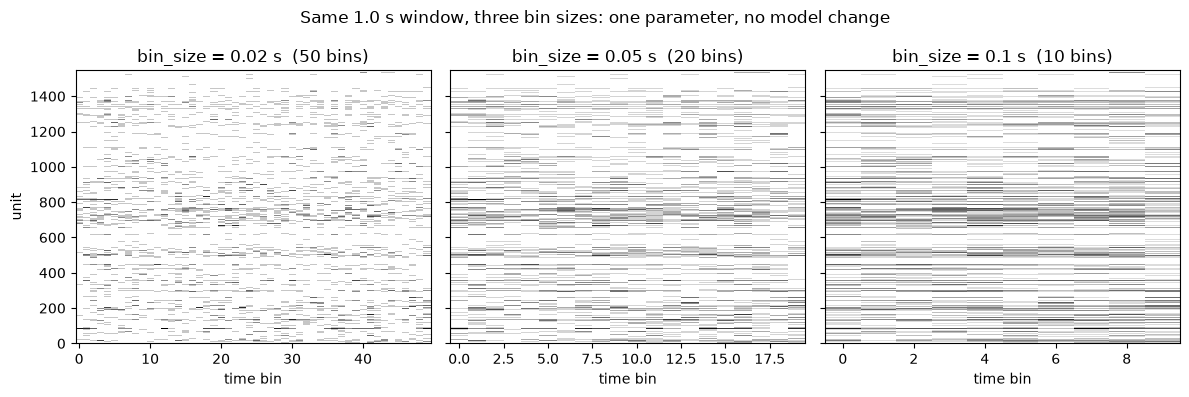

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, bs in zip(axes, [0.02, 0.05, 0.1]):
    s = demo_rec.slice(DEMO_T0, DEMO_T0 + 1.0)
    Xd = bin_spikes(s.spikes, num_units=len(s.units), bin_size=bs)
    ax.imshow(
        np.log1p(Xd.T),
        aspect="auto",
        cmap="Greys",
        origin="lower",
        interpolation="nearest",
    )
    ax.set_title(f"bin_size = {bs} s  ({Xd.shape[0]} bins)")
    ax.set_xlabel("time bin")
axes[0].set_ylabel("unit")
fig.suptitle("Same 1.0 s window, three bin sizes: one parameter, no model change")
plt.tight_layout()
plt.show()

## 3. Longer or shorter context window

The context window is how much time each sample spans; it lives in the
sampler/slice length, not in the data. A 2.0 s window simply yields 100 target
samples (at 50 Hz) and `2.0 / bin_size` input bins.

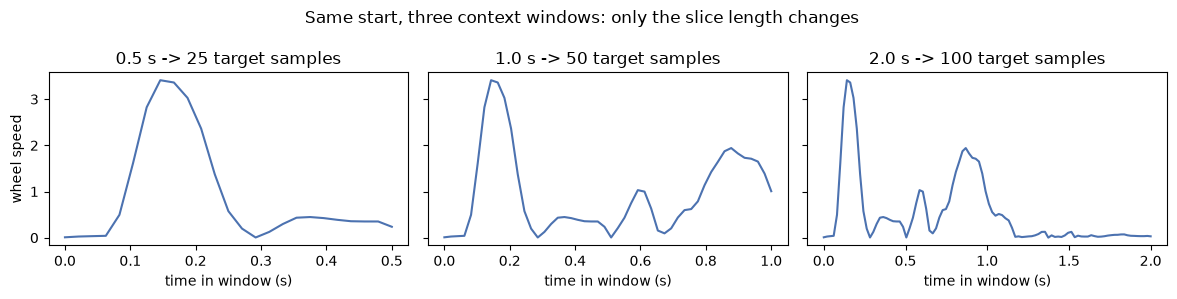

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, L in zip(axes, [0.5, 1.0, 2.0]):
    s = demo_rec.slice(DEMO_T0, DEMO_T0 + L)
    y = np.asarray(s.wheel.speed)
    ax.plot(np.linspace(0, L, len(y)), y, color="#4C72B0")
    ax.set_title(f"{L} s -> {len(y)} target samples")
    ax.set_xlabel("time in window (s)")
axes[0].set_ylabel("wheel speed")
fig.suptitle("Same start, three context windows: only the slice length changes")
plt.tight_layout()
plt.show()

## 4. Augmentation via composable transforms

Transforms attach with `transform=` and chain with `Compose`; they run inside
`__getitem__`, so augmentation is re-drawn every epoch. Here a random 0.8 s crop
of the same window (a different crop each call). *(Time-warping augmentations
like `RandomTimeScaling` also exist; we revisit those separately.)*

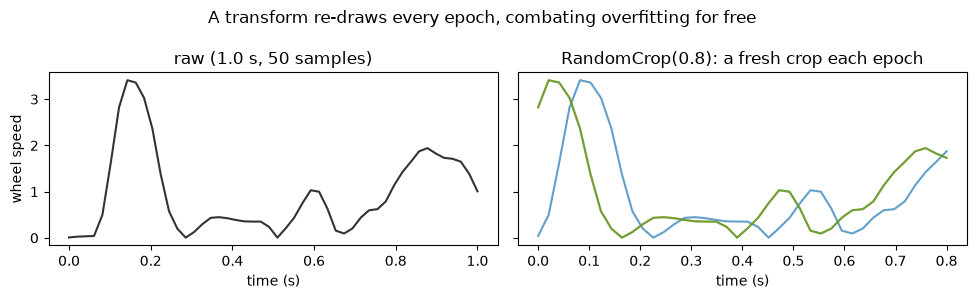

In [25]:
augment = Compose([RandomCrop(0.8)])
base = demo_rec.slice(DEMO_T0, DEMO_T0 + 1.0)
y_base = np.asarray(base.wheel.speed)

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].plot(np.linspace(0, 1.0, len(y_base)), y_base, color="#333333")
axes[0].set_title(f"raw (1.0 s, {len(y_base)} samples)")
for _ in range(3):
    a = augment(demo_rec.slice(DEMO_T0, DEMO_T0 + 1.0))
    y_a = np.asarray(a.wheel.speed)
    axes[1].plot(np.linspace(0, len(y_a) / 50.0, len(y_a)), y_a, alpha=0.7)
axes[1].set_title("RandomCrop(0.8): a fresh crop each epoch")
for ax in axes:
    ax.set_xlabel("time (s)")
axes[0].set_ylabel("wheel speed")
fig.suptitle("A transform re-draws every epoch, combating overfitting for free")
plt.tight_layout()
plt.show()

## 5. Mask or select units

Units are a labelled axis, so you can drop or select them declaratively.
`UnitDropout` keeps a random subset each sample (augmentation / regularizer);
`UnitFilter` keeps a fixed subset, e.g. one brain region, turning "which region
drives wheel decoding?" into a one-line ablation.

UnitDropout: 1547 -> 43 units kept
UnitDropout: 1547 -> 216 units kept
UnitDropout: 1547 -> 236 units kept
UnitDropout: 1547 -> 261 units kept
UnitDropout: 1547 -> 71 units kept


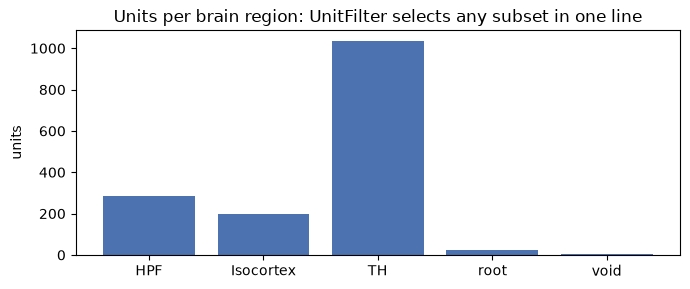

UnitFilter to thalamus: 1547 -> 1035 units


In [26]:
# (a) UnitDropout: a different random subset of units each call
for _ in range(5):
    before = len(demo_rec.slice(DEMO_T0, DEMO_T0 + 1.0).units)
    after = len(
        UnitDropout(field="spikes")(demo_rec.slice(DEMO_T0, DEMO_T0 + 1.0)).units
    )
    print(f"UnitDropout: {before} -> {after} units kept")

# (b) UnitFilter: keep only units in one brain region (cosmos atlas)
regions = np.asarray(demo_rec.units.region_cosmos)
labels, counts = np.unique(regions, return_counts=True)
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar([r.decode() for r in labels], counts, color="#4C72B0")
ax.set_ylabel("units")
ax.set_title("Units per brain region: UnitFilter selects any subset in one line")
plt.tight_layout()
plt.show()

th_filter = UnitFilter(
    mask_fn=lambda u: np.asarray(u.region_cosmos) == b"TH", field="spikes"
)
n_before = len(demo_rec.slice(DEMO_T0, DEMO_T0 + 1.0).units)
n_after = len(th_filter(demo_rec.slice(DEMO_T0, DEMO_T0 + 1.0)).units)
print(f"UnitFilter to thalamus: {n_before} -> {n_after} units")

## 6. Sampling window with jitter

`TrialSampler` emits the same fixed windows every epoch (reproducible eval).
`RandomFixedWindowSampler` applies a fresh random temporal jitter each epoch, so
the model sees slightly shifted positions within every interval: more effective
data, less positional overfitting. Only the sampler changes.

In [27]:
jitter_sampler = RandomFixedWindowSampler(
    sampling_intervals={RECORDING_ID: demo_iv}, window_length=1.0
)
fixed_sampler = TrialSampler(sampling_intervals={RECORDING_ID: demo_iv})


def first_starts(sampler, n=6):
    return [round(float(idx.start), 2) for idx in list(sampler)[:n]]


print("RandomFixedWindowSampler (jitter, new positions each epoch):")
print("  epoch 1:", first_starts(jitter_sampler))
print("  epoch 2:", first_starts(jitter_sampler))
print("TrialSampler (fixed windows, identical each epoch):")
print("  epoch 1:", first_starts(fixed_sampler))
print("  epoch 2:", first_starts(fixed_sampler))

RandomFixedWindowSampler (jitter, new positions each epoch):
  epoch 1: [184.37, 464.2, 649.73, 180.23, 206.78, 77.38]
  epoch 2: [322.09, 206.78, 328.34, 565.35, 577.9, 585.89]
TrialSampler (fixed windows, identical each epoch):
  epoch 1: [45.57, 48.69, 56.48, 61.76, 65.9, 69.09]
  epoch 2: [45.57, 48.69, 56.48, 61.76, 65.9, 69.09]
